In [1]:
!pip install flask-ngrok
!pip install Flask
!pip install fastapi uvicorn
!pip install pyngrok


In [2]:
# Step 1: Install pyngrok (don't use flask-ngrok anymore)
!pip install pyngrok

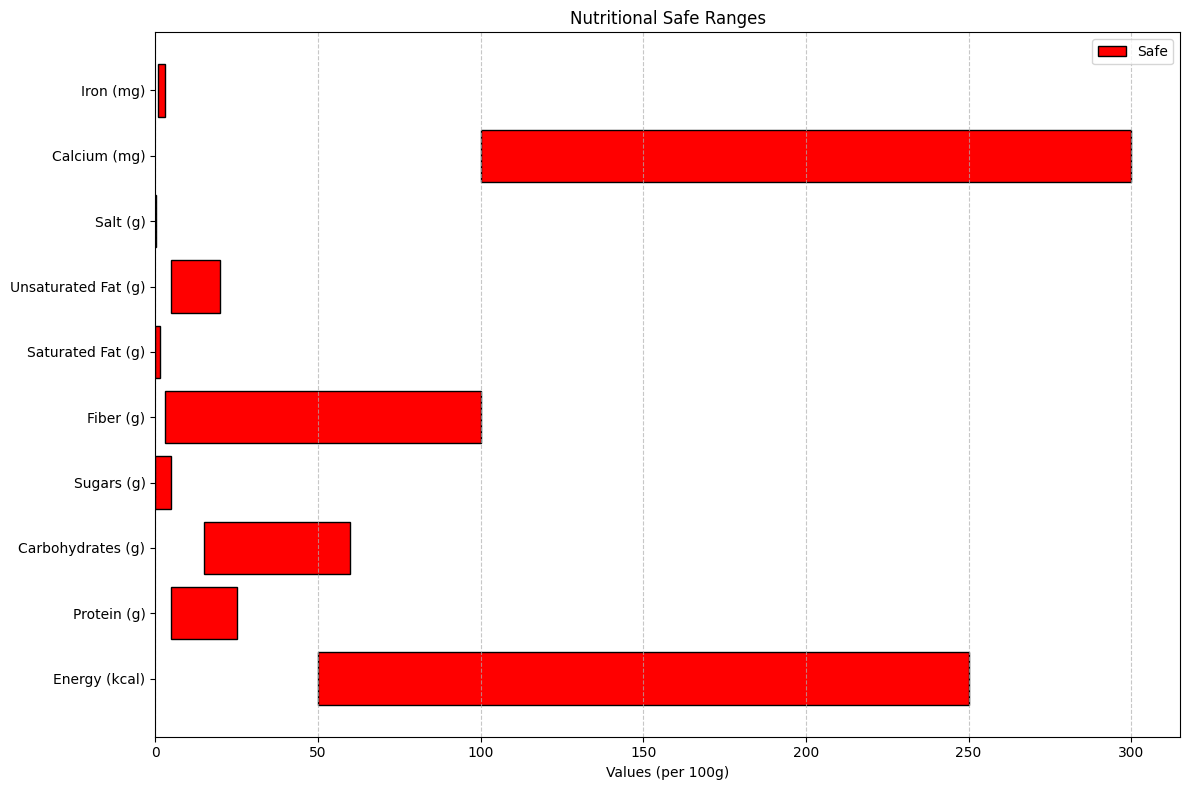

In [3]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np

# Nutrient data
nutrients = [
    "Energy (kcal)", "Protein (g)", "Carbohydrates (g)", "Sugars (g)",
    "Fiber (g)", "Saturated Fat (g)", "Unsaturated Fat (g)",
    "Salt (g)", "Calcium (mg)", "Iron (mg)"
]
safe_ranges = [
    (50, 250), (5, 25), (15, 60), (0, 5), (3, 100), (0, 1.5), (5, 20),
    (0, 0.3), (100, 300), (1, 3)
]

# Plotting
plt.figure(figsize=(12, 8))
x = np.arange(len(nutrients))

# Plot safe ranges as bars
for i, (low, high) in enumerate(safe_ranges):
    plt.barh(i, high - low, left=low, color='red', edgecolor='black', label='Safe' if i == 0 else "")

# Add labels and title
plt.yticks(x, nutrients)
plt.xlabel("Values (per 100g)")
plt.title("Nutritional Safe Ranges")
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [4]:
# Download the gzipped CSV file directly from the URL
!wget -O openfoodfacts_products.csv.gz https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz

'wget' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
import pandas as pd

# Load the gzipped CSV file into a pandas DataFrame
# pandas can automatically handle .gz compressed files
# The previous error suggests the delimiter might not be a comma, often it's a semicolon for Open Food Facts data.
# The current error suggests further parsing issues, so we'll try the 'python' engine for more robustness.
df_foodfacts = pd.read_csv('en.openfoodfacts.org.products.csv.gz', compression='gzip', sep=';', encoding='utf-8', engine='python')

# Display the first few rows of the DataFrame
display(df_foodfacts.head())

FileNotFoundError: [Errno 2] No such file or directory: 'openfoodfacts_products.csv.gz'

In [ ]:
# Check the shape of the dataset
print("Shape of the dataset:", df_foodfacts.shape)

# List all columns
print("Columns:", df_foodfacts.columns.tolist())

# Check the distribution of the target variable
print("Distribution of nutriscore_grade:")
print(df_foodfacts['nutriscore_grade'].value_counts())

NameError: name 'df_foodfacts' is not defined

In [ ]:
# Select relevant features based on Nutri-Score calculation
features = ['energy_100g', 'saturated-fat_100g', 'sugars_100g', 'fiber_100g',
            'proteins_100g', 'salt_100g', 'fruits-vegetables-nuts-estimate_100g', 'carbohydrates_100g']
target = 'nutriscore_grade'

# Check for missing values in selected features and target
print("Missing values in features:")
print(df_foodfacts[features].isnull().sum())
print("Missing values in target:")
print(df_foodfacts[target].isnull().sum())

# Impute missing values with mean for numerical features
for feature in features:
    if df_foodfacts[feature].dtype in ['float64', 'int64']:
        df_foodfacts[feature].fillna(df_foodfacts[feature].mean(), inplace=True)

# Drop rows where target is missing
df = df_foodfacts.dropna(subset=[target])

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode the target variable
le = LabelEncoder()
df_foodfacts[target] = le.fit_transform(df_foodfacts[target])

# Split the data with stratification to ensure all grades are represented
X = df_foodfacts[features]
y = df_foodfacts[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, shuffle=True,
                                                    stratify=y)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Logistic Regression
logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train_scaled, y_train)
y_pred_logregight = logreg.predict(X_test_scaled)

In [ ]:
# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logregight))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_logregight))
print("Classification Report:\n", classification_report(y_test, y_pred_logregight))

In [ ]:
from sklearn.svm import SVC

# SVM with linear kernel
svm_linear = SVC(kernel='linear', class_weight='balanced')
svm_linear.fit(X_train_scaled, y_train)
y_pred_svm_linear = svm_linear.predict(X_test_scaled)
print("SVM Linear Accuracy:", accuracy_score(y_test, y_pred_svm_linear))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_linear))
print("Classification Report:\n", classification_report(y_test, y_pred_svm_linear))

# SVM with polynomial kernel
svm_poly = SVC(kernel='poly', degree=3, class_weight='balanced')
svm_poly.fit(X_train_scaled, y_train)
y_pred_svm_poly = svm_poly.predict(X_test_scaled)
print("SVM Polynomial Accuracy:", accuracy_score(y_test, y_pred_svm_poly))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_poly))
print("Classification Report:\n", classification_report(y_test, y_pred_svm_poly))

# SVM with RBF kernel
svm_rbf = SVC(kernel='rbf', class_weight='balanced')
svm_rbf.fit(X_train_scaled, y_train)
y_pred_svm_rbf = svm_rbf.predict(X_test_scaled)
print("SVM RBF Accuracy:", accuracy_score(y_test, y_pred_svm_rbf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_rbf))
print("Classification Report:\n", classification_report(y_test, y_pred_svm_rbf))

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)  # No scaling needed
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)  # No scaling needed
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plot Decision Tree
plt.figure(figsize=(10, 30))  # Reduced size to something more viewable
plot_tree(
    dt,
    feature_names=features,
    class_names=list(map(str, le.classes_)),  # Ensure class names are strings
    filled=True,
    max_depth=3
)
plt.show()

In [ ]:
import numpy as np

# Feature Importances from Random Forest
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=90)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
from sklearn.svm import SVC

# Apply PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train SVM on PCA components
svm_rbf_pca = SVC(kernel='rbf', class_weight='balanced')
svm_rbf_pca.fit(X_train_pca, y_train)

# Create a meshgrid with a finer resolution
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),  # Higher resolution
                     np.linspace(y_min, y_max, 300))

# Predict on meshgrid
Z = svm_rbf_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Define Nutri-Score colors
nutriscore_colors = {
    0: "#008000",  # Green (A)
    1: "#ADFF2F",  # Light Green (B)
    2: "#FFA500",  # Orange (C)
    3: "#FF8C00",  # Light Orange (D)
    4: "#FF0000"   # Red (E)
}

# Create colormap
cmap = mcolors.ListedColormap([nutriscore_colors[i] for i in sorted(nutriscore_colors.keys())])

# Plot decision boundary with Nutri-Score colors
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.4, cmap=cmap)  # Background colored by SVM regions
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                      c=y_train, cmap=cmap, edgecolor='k', linewidth=0.5)  # Data points

# Add color legend
plt.colorbar(scatter, ticks=range(len(nutriscore_colors)), label="Nutri-Score Grades")

plt.title("SVM RBF Decision Boundaries with PCA & Nutri-Score Colors")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression on PCA components
logreg_pca = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg_pca.fit(X_train_pca, y_train)

# Predict on meshgrid
Z_logreg = logreg_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z_logreg = Z_logreg.reshape(xx.shape)

# Define Nutri-Score colors
nutriscore_colors = {
    0: "#008000",  # Green (A)
    1: "#ADFF2F",  # Light Green (B)
    2: "#FFA500",  # Orange (C)
    3: "#FF8C00",  # Light Orange (D)
    4: "#FF0000"   # Red (E)
}

# Create colormap
cmap = mcolors.ListedColormap([nutriscore_colors[i] for i in sorted(nutriscore_colors.keys())])

# Plot decision boundary with Nutri-Score colors
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z_logreg, alpha=0.4, cmap=cmap)  # Background colored by logistic regression regions
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                      c=y_train, cmap=cmap, edgecolor='k', linewidth=0.5)  # Data points

# Add color legend
plt.colorbar(scatter, ticks=range(len(nutriscore_colors)), label="Nutri-Score Grades")

plt.title("Logistic Regression Decision Boundaries with PCA & Nutri-Score Colors")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


In [ ]:
# Summarize accuracies
accuracies = {
    'Logistic Regression': accuracy_score(y_test, y_pred_logregight),
    'SVM Linear': accuracy_score(y_test, y_pred_svm_linear),
    'SVM Polynomial': accuracy_score(y_test, y_pred_svm_poly),
    'SVM RBF': accuracy_score(y_test, y_pred_svm_rbf),
    'Random Forest': accuracy_score(y_test, y_pred_rf),
    'Decision Tree': accuracy_score(y_test, y_pred_dt)
}

print("Model Accuracies:")
for model, acc in accuracies.items():
    print(f"{model}: {acc:.4f}")

In [ ]:
print("Enter the following nutritional information per 100g:")

# Inputs for the 7 original features
energy_100g = float(input("Energy (kcal) [energy_100g]: "))
saturated_fat_100g = float(input("Saturated fat (g) [saturated-fat_100g]: "))
sugars_100g = float(input("Sugars (g) [sugars_100g]: "))
fiber_100g = float(input("Fiber (g) [fiber_100g]: "))
proteins_100g = float(input("Proteins (g) [proteins_100g]: "))
salt_100g = float(input("Salt (g) [salt_100g]: "))
fruits_veggies_nuts_estimate = float(input("Fruits, Vegetables, Nuts estimate (%) [fruits-vegetables-nuts-estimate_100g]: "))

# Additional feature: carbohydrates (g)
carbohydrates_100g = float(input("Carbohydrates (g) [carbohydrates_100g]: "))

# Build the feature vector with 8 features.
input_features = [
    energy_100g,
    saturated_fat_100g,
    sugars_100g,
    fiber_100g,
    proteins_100g,
    salt_100g,
    fruits_veggies_nuts_estimate,
    carbohydrates_100g

]

In [ ]:
import numpy as np
import warnings
import pandas as pd
from sklearn.utils._testing import ignore_warnings
from sklearn.exceptions import ConvergenceWarning

# Suppress warnings about feature names and model warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Assuming input_features is already prepared with correct order & 9 features.
# Also assuming 'features' contains feature names in same order as input_features.
input_dict = dict(zip(features, input_features))
input_df = pd.DataFrame([input_dict])  # Create dataframe with feature names

# Scale input features using the fitted scaler (only for models that require it)
input_features_scaled = scaler.transform(input_df)

# Individual predictions
predictions = {}
predictions['lr'] = logreg.predict(input_features_scaled)[0]
predictions['svm_linear'] = svm_linear.predict(input_features_scaled)[0]
predictions['svm_poly'] = svm_poly.predict(input_features_scaled)[0]
predictions['svm_rbf'] = svm_rbf.predict(input_features_scaled)[0]
predictions['rf'] = rf.predict(input_df)[0]  # non-scaled
predictions['dt'] = dt.predict(input_df)[0]  # non-scaled

# Model weights based on accuracy
weights = {
    'lr': 0.5046,
    'svm_linear': 0.5350,
    'svm_poly': 0.5346,
    'svm_rbf': 0.6165,
    'rf': 0.8949,
    'dt': 0.8655
}

# Voting mechanism
vote_sum = {}
for model, pred in predictions.items():
    vote_sum[pred] = vote_sum.get(pred, 0) + weights[model]

# Final prediction (weighted majority vote)
final_prediction_numeric = max(vote_sum, key=vote_sum.get)

# Explicit mapping from numeric prediction to Nutri-Score grade
grade_map = {
    0: 'A',
    1: 'B',
    2: 'C',
    3: 'D',
    4: 'E'
}
final_grade = grade_map.get(final_prediction_numeric, "Unknown")

# Display result
print("\n✅ Predicted Nutri‑Score Grade:", final_grade)


In [ ]:
print("Scaler mean:", scaler.mean_)
print("Scaler std:", scaler.scale_)
print("Logistic Coefficients:", logreg.coef_)
print("Logistic Intercept:", logreg.intercept_)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Assuming y_test and y_pred_logreg are already defined

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix for {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


plot_confusion_matrix(y_test, y_pred_logregight, "Logistic Regression")
plot_confusion_matrix(y_test, y_pred_svm_linear, "SVM Linear")
plot_confusion_matrix(y_test, y_pred_svm_poly, "SVM Polynomial")
plot_confusion_matrix(y_test, y_pred_svm_rbf, "SVM RBF")
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")
plot_confusion_matrix(y_test, y_pred_dt, "Decision Tree")